In [1]:
# Import Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Configure matplotlib for inline display in Jupyter
%matplotlib inline

In [2]:
#set up the parameters (retrieve hourly precipitation data for London & Seattle)

# Step 1: Set Up Parameters

# Location coordinates for London
london_lat = 40.7128
london_lon = -74.0060

#location coordinates for Seattle
seattle_lat = 47.6062
seattle_lon = -122.3321

# Date range
start_date = '2022-01-01'
end_date = '2022-12-31'  # One year of data

# Variables to fetch
hourly_variable = ['precipitation']


In [3]:
#api request for london

base_url = 'https://archive-api.open-meteo.com/v1/archive'

london_params = {
    'latitude': london_lat,
    'longitude': london_lon,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': hourly_variable,
    'timezone': 'UTC'
}

london_response = requests.get(base_url, params=london_params)

In [4]:
#check if london data fetch worked
if london_response.status_code == 200:
    print("London data fetched successfully!")
else:
    print(f"London request failed. Status code: {london_response.status_code}")

London data fetched successfully!


In [5]:
#convert london data to a dataframe

data = london_response.json()
hourly_data = data['hourly']

london_df = pd.DataFrame(hourly_data)

london_df.head()

,time,precipitation
0,2022-01-01T00:00,0.0
1,2022-01-01T01:00,0.0
2,2022-01-01T02:00,0.0
3,2022-01-01T03:00,0.0
4,2022-01-01T04:00,0.0


In [6]:
#api request for Seattle

#seattle params
seattle_params = {
    'latitude': seattle_lat,
    'longitude': seattle_lon,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': hourly_variable,
    'timezone': 'UTC'
}

seattle_response = requests.get(base_url, params=seattle_params)

In [7]:
#check if Seattle data fetch worked
if seattle_response.status_code == 200:
    print("Seattle data fetched successfully!")
else:
    print(f"Seattle request failed. Status code: {seattle_response.status_code}")

Seattle data fetched successfully!


In [8]:
#convert seattle data to a dataframe

data = seattle_response.json()
hourly_data = data['hourly']

seattle_df = pd.DataFrame(hourly_data)
seattle_df.head()

,time,precipitation
0,2022-01-01T00:00,0.0
1,2022-01-01T01:00,0.0
2,2022-01-01T02:00,0.0
3,2022-01-01T03:00,0.0
4,2022-01-01T04:00,0.0


In [9]:
#clean the london dataframe

#convert 'time" column to datetime
london_df['time'] = pd.to_datetime(london_df['time'])

#set time as the index
london_df.set_index('time', inplace=True)

#check for missing values
london_df.isnull().sum()

precipitation    0
dtype: int64

In [10]:
#clean the Seattle dataframe

#convert 'time' column to datetime
seattle_df['time'] =pd.to_datetime(seattle_df['time'])

#set time to index
seattle_df.set_index('time', inplace=True)

#check for missing values
seattle_df.isnull().sum()

precipitation    0
dtype: int64

In [15]:
#resample hourly data to weekly totals
london_weekly = london_df.resample('W').sum()
seattle_weekly = seattle_df.resample('W').sum()

In [24]:
#identify which city has the most rainfall overall
london_total = london_weekly['precipitation'].sum()
seattle_total = seattle_weekly['precipitation'].sum()

london_total, seattle_total

(np.float64(1381.1999999999998), np.float64(1131.1))

In [33]:
london_weekly.describe()

,precipitation
count,53.000000
mean,26.060377
std,31.563954
min,0.700000
25%,10.600000
50%,18.800000
75%,32.500000
max,214.600000


In [34]:
seattle_weekly.describe()

,precipitation
count,53.000000
mean,21.341509
std,26.477475
min,0.000000
25%,2.100000
50%,10.900000
75%,35.500000
max,134.700000


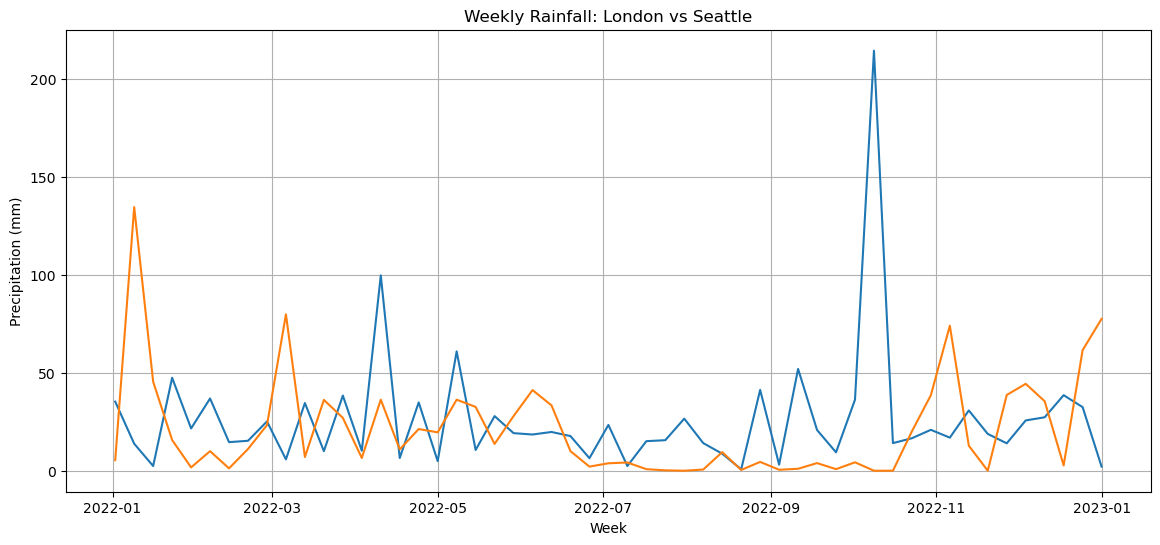

In [32]:
#plot London and Seattle
plt.figure(figsize=(14,6))
plt.plot(london_weekly.index, london_weekly['precipitation'], label='London')
plt.plot(seattle_weekly.index, seattle_weekly['precipitation'], label='Seattle')

plt.xlabel('Week')
plt.ylabel('Precipitation (mm)')
plt.title('Weekly Rainfall: London vs Seattle')
plt.grid(True)
plt.show()
